# 03 — Feature Engineering & Hypothesis Development
**Project:** Audible Audiobook Analytics  
**Team:** Team Mars  
**Author:** Ugen Basnet  
**Week:** 4  

This notebook prepares the final feature set for both models.  
Input: `../data/audible_cleaned.csv`  
Output: `../data/model_ready.csv` — used directly by Ugen's modeling notebooks.

### Steps
1. Load cleaned data
2. Engineer new features
3. Encode categorical variables
4. Create target variables
5. Feature selection & justification
6. Hypothesis statements
7. Check final feature matrix
8. Export

---
## 1. Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/audible_cleaned.csv', parse_dates=['releasedate'])

print(f'Shape: {df.shape}')
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (87419, 10)


,name,author,narrator,language,duration_minutes,releasedate,release_year,star_score,num_ratings,price
0,"Surely You're Joking, Mr. Feynman!",Richard P.Feynman,Raymond Todd,English,691.00,1998-12-27,1998,4.5,328.0,773.0
1,"Men Are from Mars, Women Are from Venus",John Gray,John Gray,English,568.00,1998-12-27,1998,4.5,166.0,1407.0
2,Letters to a Young Poet,"Rainer Maria Rilke,Stephen Mitchell-translator",Stephen Mitchell,English,78.00,1998-12-27,1998,5.0,2.0,233.0
3,"Rhetoric, Poetics and Logic",Aristotle,Frederick Davidson,English,808.00,1999-05-10,1999,0.0,0.0,773.0
4,Wealth of Nations,Adam Smith,Michael Edwards,English,1656.82,1999-05-10,1999,0.0,0.0,1338.0


---
## 2. Engineer New Features

The raw cleaned columns are not all directly usable as model inputs.  
We need to create three new features:

| Feature | Reason |
|---------|--------|
| `log_num_ratings` | `num_ratings` is extremely right-skewed — log transform normalises it |
| `is_top_narrator` | Binary flag: 1 if narrator is in the top 20 most prolific, else 0 |
| `is_top_author`   | Same logic for authors |

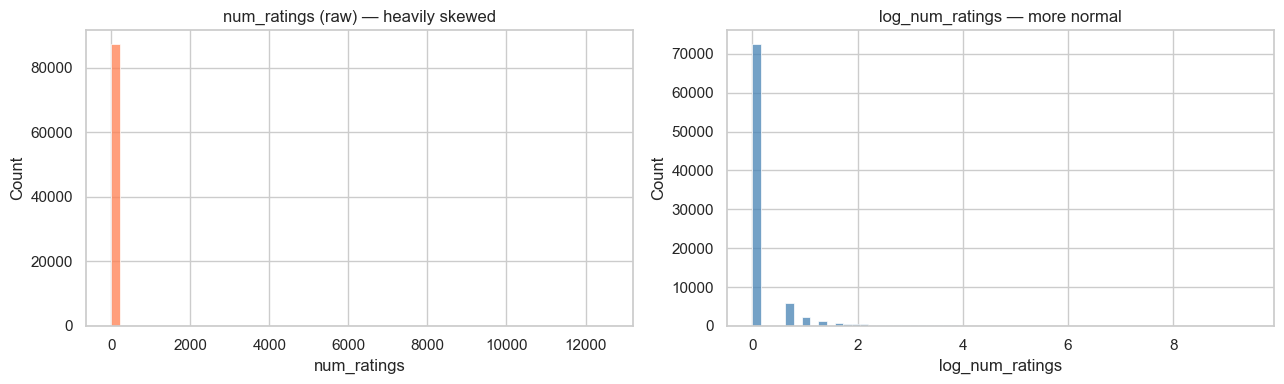

num_ratings     skewness: 97.24
log_num_ratings skewness: 3.89


In [2]:
# --- Log transform of num_ratings ---
# Adding 1 before log avoids log(0) errors for books with zero ratings
df['log_num_ratings'] = np.log1p(df['num_ratings'])

# Verify the transform reduced skew
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['num_ratings'],       bins=60, ax=axes[0], color='coral')
axes[0].set_title('num_ratings (raw) — heavily skewed')
sns.histplot(df['log_num_ratings'],   bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('log_num_ratings — more normal')
plt.tight_layout()
plt.savefig('../outputs/plots/log_transform_comparison.png', dpi=150)
plt.show()

print(f'num_ratings     skewness: {df["num_ratings"].skew():.2f}')
print(f'log_num_ratings skewness: {df["log_num_ratings"].skew():.2f}')

**Why this matters:** Linear and logistic regression both perform better when features are not heavily skewed. A skewness value closer to 0 after the transform confirms it worked.

In [3]:
# --- is_top_narrator ---
# Top 20 narrators by frequency (most prolific in the catalog)
top_narrators = df['narrator'].value_counts().head(20).index.tolist()
df['is_top_narrator'] = df['narrator'].isin(top_narrators).astype(int)

print(f'Top 20 narrators cover: {df["is_top_narrator"].sum()} books ({df["is_top_narrator"].mean()*100:.1f}% of catalog)')
print('\nTop 20 narrators:')
print(top_narrators)

Top 20 narrators cover: 5528 books (6.3% of catalog)

Top 20 narrators:
['anonymous', '矢島雅弘,石橋遊', 'Intuitive', 'uncredited', '中西貴之,B J', 'Book Buddy Digital Media', 'div.', 'ДмитрийЕвстратов', 'Bill Brown', 'Sean Pratt', 'Karlheinz Gabor', 'Tom Parks', 'Anonymous', 'Paul Boehmer', 'Walter Dixon', 'Abby Craden', 'Bob Souer', 'Grover Gardner', 'Thomas Rike', 'Aimee Lilly']


In [4]:
# --- is_top_author ---
top_authors = df['author'].value_counts().head(20).index.tolist()
df['is_top_author'] = df['author'].isin(top_authors).astype(int)

print(f'Top 20 authors cover: {df["is_top_author"].sum()} books ({df["is_top_author"].mean()*100:.1f}% of catalog)')
print('\nTop 20 authors:')
print(top_authors)

Top 20 authors cover: 4128 books (4.7% of catalog)

Top 20 authors:
['矢島雅弘,石橋遊', 'Smart Reading', '中西貴之,B J', 'div.', 'Online Studio Productions', 'William Shakespeare', 'Bill Brown', 'J.M.Gardner', 'Innovative Language Learning', 'Gertrude Chandler Warner', 'i Minds', 'Thomas Rike', 'N.N.', '志麻絹依', 'Innovative Language Learning LL C', 'Hans Christian Andersen', 'One Mediai PL TD', 'Dick Sutphen', '高橋御山人', 'P MP Management Factory']


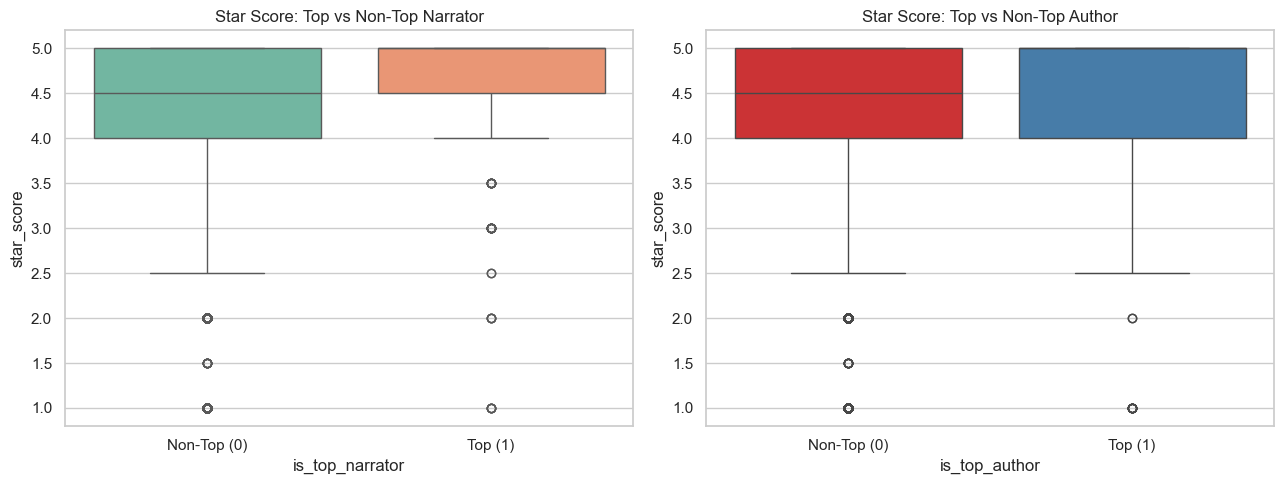

In [5]:
# Visual check: does being a top narrator affect star score?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df[df['star_score'] > 0], x='is_top_narrator', y='star_score',
            palette='Set2', ax=axes[0])
axes[0].set_title('Star Score: Top vs Non-Top Narrator')
axes[0].set_xticklabels(['Non-Top (0)', 'Top (1)'])

sns.boxplot(data=df[df['star_score'] > 0], x='is_top_author', y='star_score',
            palette='Set1', ax=axes[1])
axes[1].set_title('Star Score: Top vs Non-Top Author')
axes[1].set_xticklabels(['Non-Top (0)', 'Top (1)'])

plt.tight_layout()
plt.savefig('../outputs/plots/top_narrator_author_vs_stars.png', dpi=150)
plt.show()

**Insight:** *(Do top narrators/authors have visibly different star score distributions? Even a small difference justifies including them as features — the model will determine statistical significance.)*

---
## 3. Encode Categorical Variables

Regression models require numeric inputs only.  
The `language` column needs to be converted to numbers.

**Strategy:** Keep the top 5 languages as individual columns (one-hot encoding), group everything else as `Language_Other`.

In [6]:
# Check language distribution before encoding
print('Language counts:')
print(df['language'].value_counts())

Language counts:
language
English             61828
German               8287
Spanish              3494
Japanese             3167
Italian              2694
French               2384
Russian              1803
Danish                935
Portuguese            526
Swedish               515
Hindi                 436
Polish                224
Finnish               197
Dutch                 190
Tamil                 160
Catalan               153
Mandarin_chinese       97
Icelandic              52
Romanian               50
Hungarian              36
Urdu                   34
Afrikaans              28
Czech                  23
Turkish                20
Greek                  18
Norwegian              16
Arabic                 16
Galician               10
Bulgarian               9
Slovene                 4
Korean                  4
Hebrew                  2
Lithuanian              2
Basque                  2
Telugu                  2
Ukrainian               1
Name: count, dtype: int64


In [7]:
# Keep top 5 languages, group the rest as 'Other'
top_languages = df['language'].value_counts().head(5).index.tolist()
print(f'Top 5 languages: {top_languages}')

df['language_grouped'] = df['language'].apply(
    lambda x: x if x in top_languages else 'Other'
)

print('\nGrouped language counts:')
print(df['language_grouped'].value_counts())

Top 5 languages: ['English', 'German', 'Spanish', 'Japanese', 'Italian']

Grouped language counts:
language_grouped
English     61828
German       8287
Other        7949
Spanish      3494
Japanese     3167
Italian      2694
Name: count, dtype: int64


In [8]:
# One-hot encode language_grouped
# drop_first=True drops 'English' to use as the reference category (avoids dummy variable trap)
language_dummies = pd.get_dummies(df['language_grouped'], prefix='lang', drop_first=True)

df = pd.concat([df, language_dummies], axis=1)

print('New language dummy columns:')
print(language_dummies.columns.tolist())
print(language_dummies.head())

New language dummy columns:
['lang_German', 'lang_Italian', 'lang_Japanese', 'lang_Other', 'lang_Spanish']
   lang_German  lang_Italian  lang_Japanese  lang_Other  lang_Spanish
0        False         False          False       False         False
1        False         False          False       False         False
2        False         False          False       False         False
3        False         False          False       False         False
4        False         False          False       False         False


**Why drop_first=True?** If you create a dummy column for every language including English, the columns become perfectly predictable from each other — this is called the **dummy variable trap** and breaks regression. Dropping one (English here) makes it the implicit baseline everything else is compared against.

---
## 4. Create Target Variables

Each model needs its own target column:

| Model | Target | Type |
|-------|--------|------|
| Linear Regression | `price` | Continuous — already exists |
| Logistic Regression | `high_rating` | Binary — needs to be created |

In [9]:
# Create binary target for logistic regression
# 1 = high rating (star_score >= 4.0)
# 0 = low rating  (star_score <  4.0, including unrated books scored as 0)

df['high_rating'] = (df['star_score'] >= 4.0).astype(int)

print('high_rating distribution:')
print(df['high_rating'].value_counts())
print(f'\nClass balance: {df["high_rating"].mean()*100:.1f}% are high-rated')

high_rating distribution:
high_rating
0    73925
1    13494
Name: count, dtype: int64

Class balance: 15.4% are high-rated


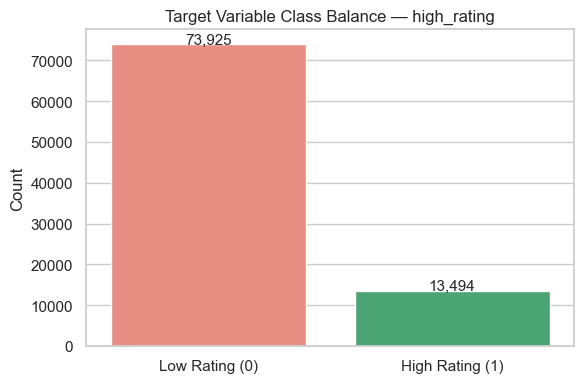

In [10]:
# Visualise the class balance
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['high_rating'].value_counts()
sns.barplot(x=['Low Rating (0)', 'High Rating (1)'], y=counts.values,
            palette=['salmon', 'mediumseagreen'], ax=ax)
ax.set_title('Target Variable Class Balance — high_rating')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/plots/target_class_balance.png', dpi=150)
plt.show()

**Insight:** *(Note the class balance. If one class massively outnumbers the other — e.g. 90% high / 10% low — the model could just predict 'high' for everything and still look accurate. If the imbalance is significant, flag it here. Ugen will handle it in the modeling notebook.)*

---
## 5. Feature Selection

Defining the exact feature sets for both models.

In [11]:
# Language dummy column names (auto-detected)
lang_cols = [c for c in df.columns if c.startswith('lang_')]
print('Language dummy columns:', lang_cols)

Language dummy columns: ['lang_German', 'lang_Italian', 'lang_Japanese', 'lang_Other', 'lang_Spanish']


In [12]:
# ============================================================
# MODEL 1 — Linear Regression
# Target: price
# ============================================================
linear_features = (
    ['duration_minutes', 'star_score', 'log_num_ratings',
     'release_year', 'is_top_narrator', 'is_top_author']
    + lang_cols
)
linear_target = 'price'

print('Linear Regression Features:')
for f in linear_features:
    print(f'  - {f}')
print(f'\nTarget: {linear_target}')

Linear Regression Features:
  - duration_minutes
  - star_score
  - log_num_ratings
  - release_year
  - is_top_narrator
  - is_top_author
  - lang_German
  - lang_Italian
  - lang_Japanese
  - lang_Other
  - lang_Spanish

Target: price


In [13]:
# ============================================================
# MODEL 2 — Logistic Regression
# Target: high_rating (binary)
# ============================================================
logistic_features = (
    ['price', 'duration_minutes', 'log_num_ratings',
     'release_year', 'is_top_narrator', 'is_top_author']
    + lang_cols
)
logistic_target = 'high_rating'

print('Logistic Regression Features:')
for f in logistic_features:
    print(f'  - {f}')
print(f'\nTarget: {logistic_target}')

Logistic Regression Features:
  - price
  - duration_minutes
  - log_num_ratings
  - release_year
  - is_top_narrator
  - is_top_author
  - lang_German
  - lang_Italian
  - lang_Japanese
  - lang_Other
  - lang_Spanish

Target: high_rating


In [14]:
# Check for nulls in selected features — must be zero before modeling
all_features = list(set(linear_features + logistic_features))

null_check = df[all_features + [linear_target, logistic_target]].isnull().sum()
print('Null check on all model columns:')
print(null_check[null_check > 0] if null_check.sum() > 0 else 'No nulls — all clear.')

Null check on all model columns:
No nulls — all clear.


In [15]:
# Drop rows where price is null (can't train linear regression without a target value)
before = len(df)
df.dropna(subset=['price', 'star_score', 'duration_minutes', 'release_year'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows dropped: {before - len(df)} | Remaining: {len(df)}')

Rows dropped: 0 | Remaining: 87419


In [16]:
# Correlation of features against each target (helps spot useful vs useless features)
print('=== Correlation with price (Linear Regression target) ===')
corr_price = df[linear_features + [linear_target]].corr()['price'].drop('price').sort_values(key=abs, ascending=False)
print(corr_price.round(3))

print('\n=== Correlation with high_rating (Logistic Regression target) ===')
corr_rating = df[logistic_features + [logistic_target]].corr()['high_rating'].drop('high_rating').sort_values(key=abs, ascending=False)
print(corr_rating.round(3))

=== Correlation with price (Linear Regression target) ===
duration_minutes    0.668
is_top_narrator    -0.226
lang_Other         -0.223
is_top_author      -0.215
lang_German        -0.188
star_score          0.182
log_num_ratings     0.143
lang_Italian       -0.138
lang_Japanese      -0.098
lang_Spanish       -0.082
release_year       -0.063
Name: price, dtype: float64

=== Correlation with high_rating (Logistic Regression target) ===
log_num_ratings     0.764
price               0.176
duration_minutes    0.162
release_year       -0.159
lang_German        -0.136
lang_Other         -0.093
lang_Spanish       -0.086
lang_Japanese      -0.083
is_top_author      -0.077
lang_Italian       -0.076
is_top_narrator    -0.071
Name: high_rating, dtype: float64


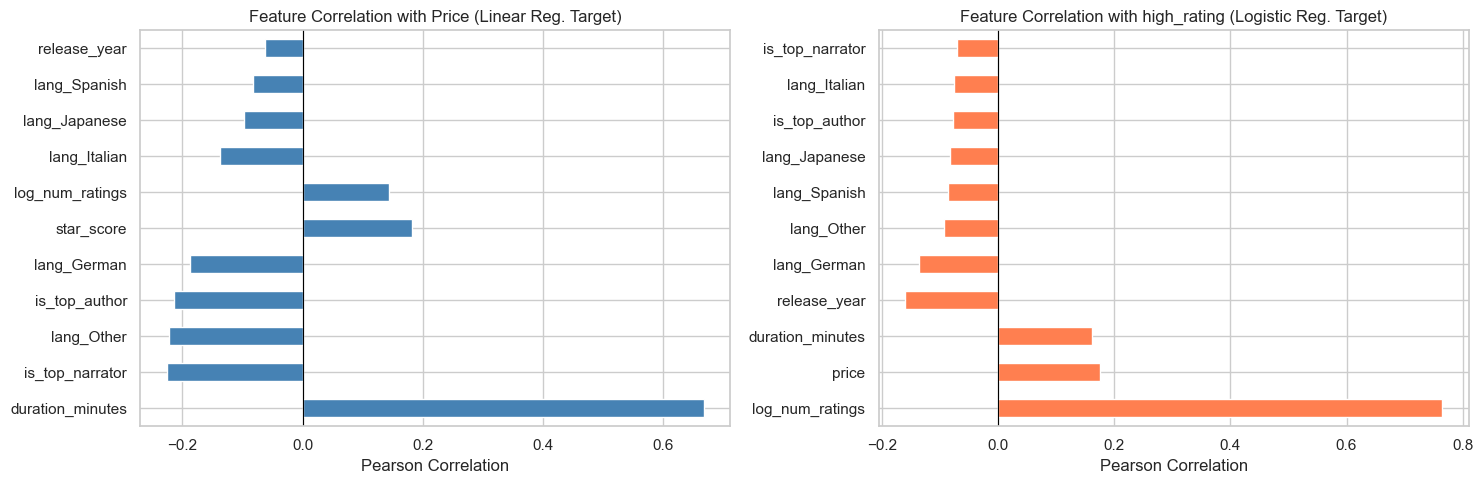

In [17]:
# Bar chart of feature correlations with price
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr_price.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Price (Linear Reg. Target)')
axes[0].set_xlabel('Pearson Correlation')

corr_rating.plot(kind='barh', ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with high_rating (Logistic Reg. Target)')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('../outputs/plots/feature_correlations.png', dpi=150)
plt.show()

**Insight:** *(Which features show the strongest correlation with each target? Any features with near-zero correlation are candidates to remove, but keep them for now — the model's p-values in Week 5 will confirm this more rigorously.)*

---
## 6. Hypothesis Statements

These are the formal statistical hypotheses we will test in Week 5.

### Model 1 — Linear Regression (Predicting Price)

**Overall Model Hypothesis**  
- H₀: None of the selected features have a significant effect on audiobook price (all coefficients = 0)  
- H₁: At least one feature has a significant effect on audiobook price

**Individual Feature Hypotheses**

| Feature | H₀ | H₁ |
|---------|----|----- |
| `duration_minutes` | Duration has no effect on price | Longer audiobooks cost more |
| `star_score` | Star score has no effect on price | Higher-rated books are priced higher |
| `log_num_ratings` | Number of ratings has no effect on price | More-reviewed books are priced differently |
| `release_year` | Release year has no effect on price | Newer books are priced higher |
| `is_top_narrator` | Narrator prominence has no effect on price | Books with top narrators cost more |
| `is_top_author` | Author prominence has no effect on price | Books by top authors cost more |
| `language` | Language has no effect on price | Audiobooks in certain languages are priced differently |

**Significance level:** α = 0.05 (we reject H₀ if p-value < 0.05)

---

### Model 2 — Logistic Regression (Classifying High Rating)

**Overall Model Hypothesis**  
- H₀: None of the selected features predict whether an audiobook is highly rated  
- H₁: At least one feature significantly predicts high vs low rating

**Individual Feature Hypotheses**

| Feature | H₀ | H₁ |
|---------|----|----- |
| `price` | Price does not predict high rating | Higher-priced books are more likely to be highly rated |
| `duration_minutes` | Duration does not predict high rating | Longer books are more/less likely to be highly rated |
| `log_num_ratings` | Rating count does not predict high rating | Books with more reviews are more likely to be highly rated |
| `release_year` | Release year does not predict high rating | Newer books are more likely to be highly rated |
| `is_top_narrator` | Narrator prominence does not predict high rating | Books with top narrators are more likely to be highly rated |
| `is_top_author` | Author prominence does not predict high rating | Books by top authors are more likely to be highly rated |
| `language` | Language does not predict high rating | Books in certain languages are more likely to be highly rated |

**Significance level:** α = 0.05

---
## 7. Final Feature Matrix Check

In [18]:
# Rebuild feature lists after any row drops
lang_cols = [c for c in df.columns if c.startswith('lang_')]

linear_features = (
    ['duration_minutes', 'star_score', 'log_num_ratings',
     'release_year', 'is_top_narrator', 'is_top_author']
    + lang_cols
)

logistic_features = (
    ['price', 'duration_minutes', 'log_num_ratings',
     'release_year', 'is_top_narrator', 'is_top_author']
    + lang_cols
)

X_linear   = df[linear_features]
y_linear   = df['price']

X_logistic = df[logistic_features]
y_logistic = df['high_rating']

print('=== Linear Regression ===')
print(f'X shape: {X_linear.shape} | y shape: {y_linear.shape}')
print(f'Features: {linear_features}')

print('\n=== Logistic Regression ===')
print(f'X shape: {X_logistic.shape} | y shape: {y_logistic.shape}')
print(f'Features: {logistic_features}')

=== Linear Regression ===
X shape: (87419, 11) | y shape: (87419,)
Features: ['duration_minutes', 'star_score', 'log_num_ratings', 'release_year', 'is_top_narrator', 'is_top_author', 'lang_German', 'lang_Italian', 'lang_Japanese', 'lang_Other', 'lang_Spanish']

=== Logistic Regression ===
X shape: (87419, 11) | y shape: (87419,)
Features: ['price', 'duration_minutes', 'log_num_ratings', 'release_year', 'is_top_narrator', 'is_top_author', 'lang_German', 'lang_Italian', 'lang_Japanese', 'lang_Other', 'lang_Spanish']


In [19]:
# Final summary stats of model-ready features
df[linear_features + ['price', 'high_rating']].describe().round(2)

,duration_minutes,star_score,log_num_ratings,release_year,is_top_narrator,is_top_author,price,high_rating
count,87419.00,87419.00,87419.00,87419.00,87419.00,87419.00,87419.00,87419.00
mean,410.63,0.77,0.27,2017.99,0.06,0.05,555.98,0.15
std,323.33,1.71,0.77,4.26,0.24,0.21,321.26,0.36
min,1.00,0.00,0.00,1998.00,0.00,0.00,0.00,0.00
25%,142.00,0.00,0.00,2016.00,0.00,0.00,268.00,0.00
50%,386.00,0.00,0.00,2020.00,0.00,0.00,585.00,0.00
75%,584.00,0.00,0.00,2021.00,0.00,0.00,755.00,0.00
max,1656.82,5.00,9.44,2025.00,1.00,1.00,1407.00,1.00


---
## 8. Export Model-Ready Dataset

In [20]:
# Save model-ready dataset — Ugen reads this in notebooks 03 and 04
model_cols = list(set(linear_features + logistic_features)) + ['price', 'high_rating', 'star_score', 'name', 'author', 'narrator']
model_cols = [c for c in model_cols if c in df.columns]  # safety check

df[model_cols].to_csv('../data/model_ready.csv', index=False)
print(f'model_ready.csv saved — shape: {df[model_cols].shape}')
print('Columns saved:')
print(sorted(model_cols))

model_ready.csv saved — shape: (87419, 18)
Columns saved:
['author', 'duration_minutes', 'high_rating', 'is_top_author', 'is_top_narrator', 'lang_German', 'lang_Italian', 'lang_Japanese', 'lang_Other', 'lang_Spanish', 'log_num_ratings', 'name', 'narrator', 'price', 'price', 'release_year', 'star_score', 'star_score']
